Replicando Soumyadip Das et al. EuroSAT dataset.

In [3]:
import random
import numpy as np
import tensorflow as tf
from pathlib import Path
from PIL import Image
import zipfile
from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Dataset - Load & Split

In [ ]:
def to_grayscale(X_rgb: np.ndarray) -> np.ndarray:
    """Rec.601 luminance. Input: (..., 3) float32. Output: (...) float32."""
    return 0.299 * X_rgb[..., 0] + 0.587 * X_rgb[..., 1] + 0.114 * X_rgb[..., 2]


DATA_DIR = Path("data/EuroSAT_RGB")
ZIP_PATH = Path("data_zip/EuroSAT_RGB.zip")
MODEL_DIR = Path("models/eurosat_denoiser")

if not (DATA_DIR.exists() and any(DATA_DIR.iterdir())):
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR.parent)

CATEGORIES = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
LABEL_MAP  = {cat: i for i, cat in enumerate(CATEGORIES)}
print("Categories:", CATEGORIES)

images, labels = [], []
for cat in CATEGORIES:
    for path in sorted((DATA_DIR / cat).glob("*.jpg")):
        img = np.array(Image.open(path).resize((64, 64)), dtype=np.float32) / 255.0
        images.append(img)
        labels.append(LABEL_MAP[cat])

X_rgb = np.stack(images)   # (N, 64, 64, 3)
y     = np.array(labels)   # (N,)

X = to_grayscale(X_rgb)    # (N, 64, 64)
print(f"Total: {X.shape}, labels: {y.shape}")

# 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Categories: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total: (27000, 64, 64), labels: (27000,)
Train: (21600, 64, 64), Val: (2700, 64, 64), Test: (2700, 64, 64)


### Noise Dataset

In [5]:
def apply_noise(X: np.ndarray, sigma: float, seed: int) -> np.ndarray:
    """I˜ = clip(I · (1 + σ · N(0,1)), 0, 1). X must be float32 in [0,1]."""
    rng = np.random.default_rng(seed)
    eps = rng.normal(0, sigma, size=X.shape).astype(np.float32)
    return np.clip(X * (1 + eps), 0.0, 1.0)

In [6]:
SIGMA = 0.1
X_train_noisy = apply_noise(X_train, sigma=SIGMA, seed=SEED)
X_test_noisy  = apply_noise(X_test,  sigma=SIGMA, seed=SEED)
print(f"Train noisy: {X_train_noisy.shape}, Test noisy: {X_test_noisy.shape}")

Train noisy: (21600, 64, 64), Test noisy: (2700, 64, 64)


Visualização

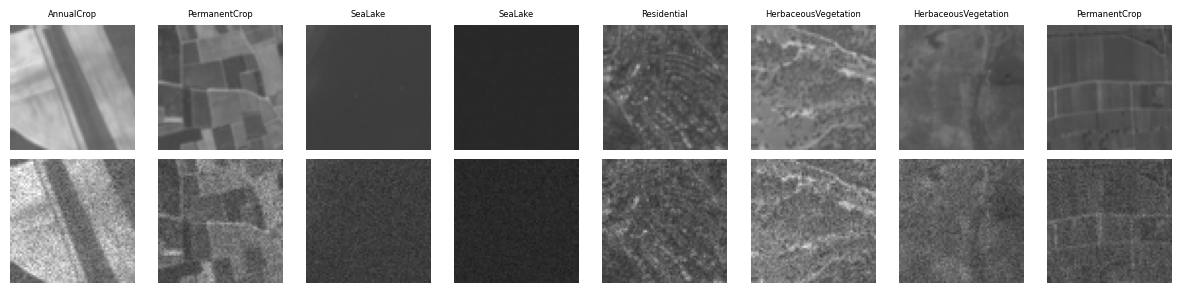

In [7]:
import matplotlib.pyplot as plt

n = 8
fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))

for col in range(n):
    axes[0, col].imshow(X_train[col],       cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(X_train_noisy[col], cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(CATEGORIES[y_train[col]], fontsize=6)
    axes[0, col].axis("off")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("clean", fontsize=9)
axes[1, 0].set_ylabel("noisy", fontsize=9)
plt.tight_layout()
plt.show()

### PCA

In [10]:
from sklearn.decomposition import PCA

N_COMPONENTS_FULL = 100
N_COMPONENTS = 18

X_train_flat = X_train.reshape(X_train.shape[0], -1)

pca = PCA(n_components=N_COMPONENTS_FULL)
pca.fit(X_train_flat)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",100
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

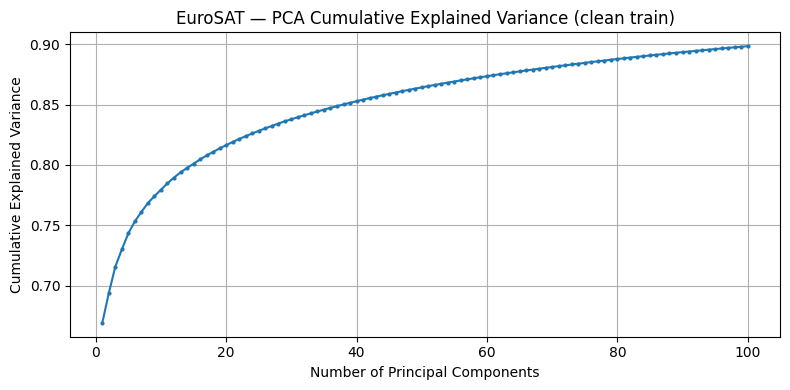

Variance explained by 100 PCs: 0.8984
Explained variance ratio added at each PC (10 first): [0.6690509  0.02467676 0.02198638 0.01423049 0.01338856 0.00990545
 0.00774623 0.00741209 0.00566784 0.00539537]


In [11]:
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, N_COMPONENTS_FULL + 1), cumulative_var, marker=".", markersize=4)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("EuroSAT — PCA Cumulative Explained Variance (clean train)")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Variance explained by {N_COMPONENTS_FULL} PCs: {cumulative_var[-1]:.4f}")
print(f"Explained variance ratio added at each PC (10 first): {pca.explained_variance_ratio_[:10]}")

The variance explained by the principal components is significantly higher then the values observed on MNIST.

The high value of variance explained by the first PC indicates there is an axis along which the images are very spread out.

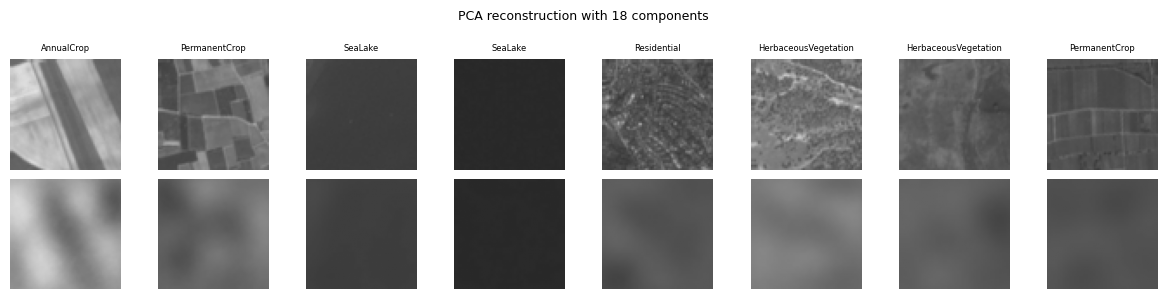

In [12]:
X_train_projected = pca.transform(X_train_flat)  # (n_train, N_COMPONENTS=100)

# reconstruct using only first num_pcs components
X_train_projected_trunc = np.zeros_like(X_train_projected)
X_train_projected_trunc[:, :N_COMPONENTS] = X_train_projected[:, :N_COMPONENTS]
X_train_reconstructed = pca.inverse_transform(X_train_projected_trunc)  # (n_train, 4096)

n = 8
fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))

for col in range(n):
    axes[0, col].imshow(X_train[col],                               cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(X_train_reconstructed[col].reshape(64, 64), cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(CATEGORIES[y_train[col]], fontsize=6)
    axes[0, col].axis("off")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("original", fontsize=8)
axes[1, 0].set_ylabel(f"{N_COMPONENTS} PCs", fontsize=8)
plt.suptitle(f"PCA reconstruction with {N_COMPONENTS} components", fontsize=9)
plt.tight_layout()
plt.show()

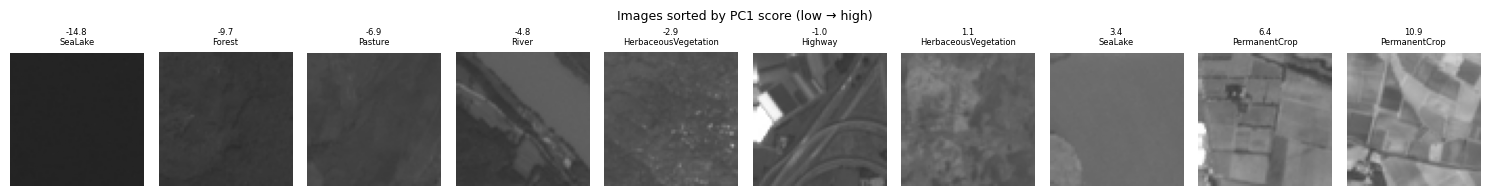

In [13]:
scores_pc1 = pca.transform(X_train_flat)[:, 0]
sorted_idx  = np.argsort(scores_pc1)

n = 10
sample_idx = [sorted_idx[int(i * len(sorted_idx) / n)] for i in range(n)]

fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2))

for col, idx in enumerate(sample_idx):
    axes[col].imshow(X_train[idx], cmap="gray", vmin=0, vmax=1)
    axes[col].set_title(f"{scores_pc1[idx]:.1f}\n{CATEGORIES[y_train[idx]]}", fontsize=6)
    axes[col].axis("off")

plt.suptitle("Images sorted by PC1 score (low → high)", fontsize=9)
plt.tight_layout()
plt.show()

The visualisations seems to indicate the first PC represents a measure of brightness in the image.

In [14]:
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_test_projected = pca.transform(X_test_flat)[:, :N_COMPONENTS]   # (n_test, N_COMPONENTS)
print(f"Test projected shape: {X_test_projected.shape}")
print(f"PC scores — mean: {X_test_projected.mean(axis=0).round(3)}")
print(f"PC scores — std:  {X_test_projected.std(axis=0).round(3)}")

Test projected shape: (2700, 18)
PC scores — mean: [-0.006  0.011 -0.019  0.02   0.008  0.017 -0.02   0.023 -0.002  0.012
  0.01   0.014  0.024  0.003  0.01  -0.012 -0.008 -0.008]
PC scores — std:  [7.822 1.434 1.417 1.097 1.094 0.963 0.831 0.843 0.694 0.702 0.675 0.651
 0.636 0.574 0.585 0.589 0.549 0.535]


### MLP Denoiser

Paper describes: 

- Input layer = Number of PC's
- Output Layer = 28 x 28 Nodes
- 1024 and 512 nodes on 2 hidden layers
- ReLU activation in between layers, sigmoid at the end
- 0.3 dropout rate
- 20 Patience

#### In this experiment

Our first test: 1024 and 2048 nodes on hidden layers and (naturaly) 64 x 64 output nodes

In [15]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.3
BATCH_SIZE = 64
PATIENCE = 20
EPOCHS = 500

model = Sequential([
    Dense(1024, activation="relu", input_shape=(N_COMPONENTS,)),
    Dropout(DROPOUT_RATE),
    Dense(2048, activation="relu"),
    Dropout(DROPOUT_RATE),
    Dense(4096, activation="relu"),
    Dropout(DROPOUT_RATE),
    Dense(2*4096, activation="relu"),
    Dropout(DROPOUT_RATE),
    Dense(4096, activation="sigmoid"),
])

model.summary()

/home/jvpcms/ime/PFC/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781963670.264821   82392 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2091 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8192)           │    33,562,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    33,558,528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,632,512 (296.14 MB)

 Trainable params: 77,632,512 (296.14 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
import wandb
from wandb.integration.keras import WandbMetricsLogger
from datetime import datetime

run_name = f"mlp_lr{LEARNING_RATE}_{datetime.now().strftime('%Y%m%d-%H%M%S')}"

wandb.init(
    project="pca-denoise-eurosat",
    name=run_name,
    config={
        "sigma": SIGMA,
        "n_components": N_COMPONENTS,
        "architecture": "1024-2048-4096-8192-4096",
        "optimizer": "adam",
        "lr": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "dropout": DROPOUT_RATE,
        "patience": PATIENCE,
        "dataset": "EuroSAT",
    },
)


class SSIMCallback(tf.keras.callbacks.Callback):
    """Injects ssim_train and ssim_val into logs each epoch for WandbMetricsLogger."""

    def __init__(self, X_train_pca, X_train_clean, X_val_pca, X_val_clean, img_shape=(64, 64)):
        super().__init__()
        self.X_train_pca   = X_train_pca
        self.X_train_clean = X_train_clean.reshape(-1, *img_shape, 1)
        self.X_val_pca     = X_val_pca
        self.X_val_clean   = X_val_clean.reshape(-1, *img_shape, 1)
        self.img_shape     = img_shape

    def _mean_ssim(self, X_pca, X_clean):
        pred = self.model.predict(X_pca, verbose=0).reshape(-1, *self.img_shape, 1)
        return float(tf.reduce_mean(tf.image.ssim(X_clean, pred, max_val=1.0)).numpy())

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            return
        logs["ssim_train"] = self._mean_ssim(self.X_train_pca, self.X_train_clean)
        logs["ssim_val"]   = self._mean_ssim(self.X_val_pca,   self.X_val_clean)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: jvpcms (jvpcms-ime) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Training

- Adam optimizer
- MSE loss
- Batches of 64
- 500 epochs
- Patience of 20

Epoch 1/500


W0000 00:00:1781963673.930784   82392 cpu_allocator_impl.cc:82] Allocation of 353894400 exceeds 10% of free system memory.
W0000 00:00:1781963674.278625   82392 cpu_allocator_impl.cc:82] Allocation of 353894400 exceeds 10% of free system memory.
I0000 00:00:1781963675.753345   90290 service.cc:153] XLA service 0x77ed4c033990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781963675.753374   90290 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781963675.794721   90290 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781963676.007979   90290 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781963676.086975   90290 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2156__.12
I0000 00:00:1781963677.01461

  7/338 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0393  

I0000 00:00:1781963687.477692   90290 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


337/338 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0146

I0000 00:00:1781963694.864328   90289 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2156__.12


338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0146

I0000 00:00:1781963704.786551   90923 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 2160 bytes spill stores, 2000 bytes spill loads

I0000 00:00:1781963705.909310   90932 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 776 bytes spill stores, 852 bytes spill loads

I0000 00:00:1781963707.075791   90924 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 2216 bytes spill stores, 2072 bytes spill loads

I0000 00:00:1781963708.048378   90926 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 2160 bytes spill stores, 2000 bytes spill loads

W0000 00:00:1781963712.764310   82392 cpu_allocator_impl.cc:82] Allocation of 134217728 exceeds 10% of free system memory.
W0000 00:00:1781963712.994682   82392 cpu_a

338/338 ━━━━━━━━━━━━━━━━━━━━ 53s 117ms/step - loss: 0.0100 - val_loss: 0.0070 - ssim_train: 0.5837 - ssim_val: 0.5720
Epoch 2/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0062 - val_loss: 0.0060 - ssim_train: 0.5913 - ssim_val: 0.5799
Epoch 3/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0055 - val_loss: 0.0057 - ssim_train: 0.5969 - ssim_val: 0.5852
Epoch 4/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0051 - val_loss: 0.0057 - ssim_train: 0.6010 - ssim_val: 0.5891
Epoch 5/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0049 - val_loss: 0.0054 - ssim_train: 0.6039 - ssim_val: 0.5916
Epoch 6/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0049 - val_loss: 0.0051 - ssim_train: 0.6068 - ssim_val: 0.5942
Epoch 7/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0048 - val_loss: 0.0054 - ssim_train: 0.6064 - ssim_val: 0.5935
Epoch 8/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0048 - val_loss: 0.0053 - ssim_train: 0.6074 - ssi

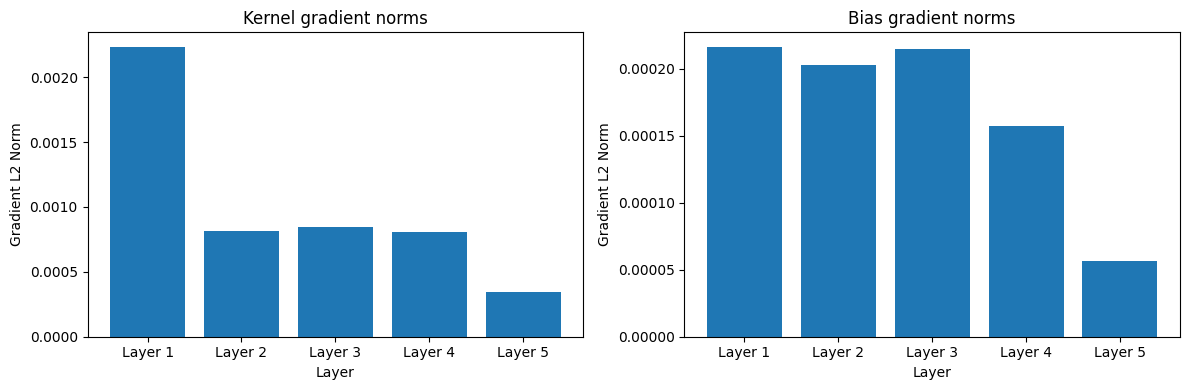

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/ssim_train,▁▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇███
epoch/ssim_val,▁▃▆▇▆▇█▇███████████▇▇▇▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄
epoch/val_loss,█▅▄▄▃▃▃▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁
epoch/epoch,57
epoch/learning_rate,0.0001
epoch/loss,0.00386
epoch/ssim_train,0.64172
epoch/ssim_val,0.588


In [17]:
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

X_train_noisy_flat = X_train_noisy.reshape(X_train_noisy.shape[0], -1)
X_train_noisy_pca  = pca.transform(X_train_noisy_flat)[:, :N_COMPONENTS]
X_train_flat       = X_train.reshape(X_train.shape[0], -1)

X_val_noisy_flat   = apply_noise(X_val, sigma=SIGMA, seed=SEED + 1).reshape(X_val.shape[0], -1)
X_val_noisy_pca    = pca.transform(X_val_noisy_flat)[:, :N_COMPONENTS]
X_val_flat         = X_val.reshape(X_val.shape[0], -1)

model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
ssim_cb    = SSIMCallback(
    X_train_noisy_pca[:1000], X_train_flat[:1000],  # subset for speed
    X_val_noisy_pca, X_val_flat,
)

history = model.fit(
    X_train_noisy_pca, X_train_flat,
    validation_data=(X_val_noisy_pca, X_val_flat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, ssim_cb, WandbMetricsLogger()],
)

# --- gradient norm bar charts ---
with tf.GradientTape() as tape:
    y_pred = model(X_train_noisy_pca[:64], training=True)
    loss   = tf.reduce_mean(tf.square(y_pred - X_train_flat[:64]))
all_grads = tape.gradient(loss, model.trainable_weights)

layer_weight_pairs = [
    (layer.name, w.name)
    for layer in model.layers
    for w in layer.trainable_weights
]

kernel_rows, bias_rows = [], []
layer_idx, prev_layer = 1, None

for (layer_name, w_name), g in zip(layer_weight_pairs, all_grads):
    if layer_name != prev_layer:
        label = f"Layer {layer_idx}"
        layer_idx += 1
        prev_layer = layer_name
    norm = float(tf.norm(g).numpy())
    if "kernel" in w_name:
        kernel_rows.append([label, norm])
    elif "bias" in w_name:
        bias_rows.append([label, norm])

kernel_table = wandb.Table(columns=["layer", "grad_norm"], data=kernel_rows)
bias_table   = wandb.Table(columns=["layer", "grad_norm"], data=bias_rows)

wandb.log({
    "grad_norm/kernel_by_layer": wandb.plot.bar(kernel_table, "layer", "grad_norm", title="Kernel Gradient Norms"),
    "grad_norm/bias_by_layer":   wandb.plot.bar(bias_table,   "layer", "grad_norm", title="Bias Gradient Norms"),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([r[0] for r in kernel_rows], [r[1] for r in kernel_rows])
axes[0].set_xlabel("Layer"); axes[0].set_ylabel("Gradient L2 Norm"); axes[0].set_title("Kernel gradient norms")
axes[1].bar([r[0] for r in bias_rows], [r[1] for r in bias_rows])
axes[1].set_xlabel("Layer"); axes[1].set_ylabel("Gradient L2 Norm"); axes[1].set_title("Bias gradient norms")
plt.tight_layout()
plt.show()

wandb.finish()


In [ ]:
X_val_reconstructed    = model.predict(X_val_noisy_pca).reshape(-1, 64, 64)
X_val_noisy_imgs       = X_val_noisy_flat.reshape(-1, 64, 64)
X_val_noisy_pca_imgs   = pca.inverse_transform(X_val_noisy_pca).reshape(-1, 64, 64)

n = 8
row_labels = ["clean", "noisy", "noisy (PCA proj.)", "reconstructed"]
fig, axes = plt.subplots(4, n, figsize=(n * 1.5, 7))

for col in range(n):
    axes[0, col].imshow(X_val[col],                  cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(X_val_noisy_imgs[col],        cmap="gray", vmin=0, vmax=1)
    axes[2, col].imshow(X_val_noisy_pca_imgs[col],    cmap="gray", vmin=0, vmax=1)
    axes[3, col].imshow(X_val_reconstructed[col],     cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(CATEGORIES[y_val[col]], fontsize=6)
    for row in range(4):
        axes[row, col].axis("off")

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=8)

plt.suptitle("Validation set — Clean / Noisy / Noisy PCA proj. / Reconstructed", fontsize=9)
plt.tight_layout()
plt.show()


85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 100 is different from 18)

: 

In [ ]:
import json

model_path = MODEL_DIR / f"{run_name}.keras"
history_path = MODEL_DIR / f"{run_name}_history.json"

model.save(model_path)
with open(history_path, 'w') as f:
    json.dump(history.history, f)